# Bike Sharing Demand Prediction — AI/ML Beginner Task

Hi! This is my submission for the AI/ML Beginner Recruitment Task.

I went with **Choice 1 — Kaggle Bike Sharing Demand**, mainly because it's a regression problem and I found the columns easier to understand than the Spotify dataset.

**Name:** [pihu chaudhary]
**Roll No:** [2026UCA1899]

**Target I'm predicting:** `count` — the total number of bikes rented in a given hour.

Quick note on where I'm at: I started learning Python and pandas about a month ago, so this notebook isn't going to be super polished — I tried to keep the code simple and explain my thinking in plain words instead of using fancy one-liners I don't fully understand yet. I followed the steps from the task PDF in order: load the data → understand it → clean it → make some graphs → prep the data for modeling → train all 5 required models → compare them at the end.

## Step 1: Loading and Understanding the Dataset

In [ ]:
# importing everything I need
# pandas and numpy for handling the data
import pandas as pd
import numpy as np

# matplotlib and seaborn for the graphs
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn stuff — splitting data, scaling, and the 5 models I need to train
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

# just making the plots look a little nicer (found this in the seaborn docs)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

In [ ]:
# loading the dataset with pandas
# (if running on Kaggle, the path is usually /kaggle/input/bike-sharing-demand/train.csv instead)
df = pd.read_csv('train.csv')

# datetime column was just plain text when I checked with .dtypes, so converting it properly
df['datetime'] = pd.to_datetime(df['datetime'])

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 10886 rows, 12 columns


### First 5 and last 5 rows

In [ ]:
# checking what the data actually looks like
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
# and the last few rows too, just to make sure nothing weird is happening at the end
df.tail()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129
10885,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88


### Shape, column names, and data types

In [ ]:
# how many rows/columns
print("Shape:", df.shape)

# what are the column names
print("\nColumns:", list(df.columns))

# what type of data is in each column
print("\nData types:\n")
print(df.dtypes)

Shape: (10886, 12)

Columns: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

Data types:

datetime      datetime64[us]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
dtype: object


### Basic statistics

In [ ]:
# describe() gives mean, min, max, std etc for all the numeric columns — pretty useful for a first look
df.describe()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399412,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454


### Numerical vs Categorical columns

I went through the columns and grouped them like this:

- **Numerical columns:** `temp`, `atemp`, `humidity`, `windspeed`, `casual`, `registered`, `count` — real numbers that can take a range of values.
- **Categorical columns:** `season`, `holiday`, `workingday`, `weather` — these are *stored* as numbers (1, 2, 3, 4...) but they actually represent groups/categories, not real quantities. Like, season 3 isn't "more" than season 1, it's just a different category that happens to be labeled with a number.
- **Datetime column:** `datetime` — a timestamp. I didn't feed this into the models directly, instead I pulled hour/month/day out of it later in the preprocessing step.

In [ ]:
numerical_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
categorical_cols = ['season', 'holiday', 'workingday', 'weather']

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

# checking what values each categorical column actually contains
print("\nUnique values in each categorical column:")
for c in categorical_cols:
    print(f"  {c}: {sorted(df[c].unique())}")

Numerical columns: ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
Categorical columns: ['season', 'holiday', 'workingday', 'weather']

Unique values in each categorical column:
  season: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  holiday: [np.int64(0), np.int64(1)]
  workingday: [np.int64(0), np.int64(1)]
  weather: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### What's the target variable?

The target here is **`count`** — total number of bikes rented in that hour. It's a number that can go up or down (not a category), so this is a **regression problem**.

One thing I noticed while poking around: `count` is literally just `casual + registered` added together (I double check this below, and it's true for every row). That means if I leave `casual`/`registered` in as features, the model would basically already know the answer — kind of like cheating. So I'm dropping both of those columns before training anything.

In [ ]:
# double-checking my theory that count = casual + registered
print("count == casual + registered for every row:", (df['casual'] + df['registered'] == df['count']).all())

count == casual + registered for every row: True


### My initial observations

A few things I noticed going through the data:

- There are **10,886 rows**, each one being a single hour of bike-sharing data from 2011–2012. Didn't spot any missing values just from eyeballing it (I check this properly in the next section anyway).
- `count` looks **skewed to the right** — most hours don't have a huge number of rentals, but there's a long tail of hours with really high counts (probably rush hour / good weather). I confirm this later with a histogram.
- `weather = 4` (I'm guessing this means something like heavy rain/snow) shows up only **once** in the whole dataset. So it's a real value, just extremely rare — I don't think the model will learn much from just one example of it, but I'm not removing it since it's not an error.

## Step 2: Data Cleaning

### Checking for missing values

In [ ]:
# isna() flags missing/null values, sum() counts them up per column
print("Missing values per column:\n")
print(df.isna().sum())
print("\nTotal missing values:", df.isna().sum().sum())

Missing values per column:

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Total missing values: 0


Good news — **zero missing values** anywhere in the dataset, so there's nothing to fill in here.

### Checking for duplicate rows

In [ ]:
# duplicated() flags rows that are an exact copy of another row
n_dupes = df.duplicated().sum()
print("Number of duplicate rows:", n_dupes)

if n_dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicate rows found — nothing to remove.")

Number of duplicate rows: 0
No duplicate rows found — nothing to remove.


### Checking for weird / invalid values

In [ ]:
# checking min/max of the numeric columns to see if anything looks off (negative humidity, crazy windspeed, etc)
df[['temp','atemp','humidity','windspeed','casual','registered','count']].agg(['min','max']).T

,min,max
temp,0.82,41.0000
atemp,0.76,45.4550
humidity,0.00,100.0000
windspeed,0.00,56.9969
casual,0.00,367.0000
registered,0.00,886.0000
count,1.00,977.0000


**What I found:** everything actually looks fine — `humidity` stays within 0–100 (makes sense, it's a percentage), `windspeed` never goes negative, `temp`/`atemp` look like normal Celsius values, and `casual`/`registered`/`count` are all zero or positive, which is what you'd expect for a "number of people" type column. I already confirmed `casual + registered = count` holds for every row too, so nothing looks broken there.

The only slightly odd thing is that one row with `weather = 4` (bad weather), but that's a genuine value, not a data error, so I'm keeping it. Nothing needed fixing or removing in this step.

## Step 3: Data Visualization

### Graph 1 — Distribution plot (spread of rental counts)

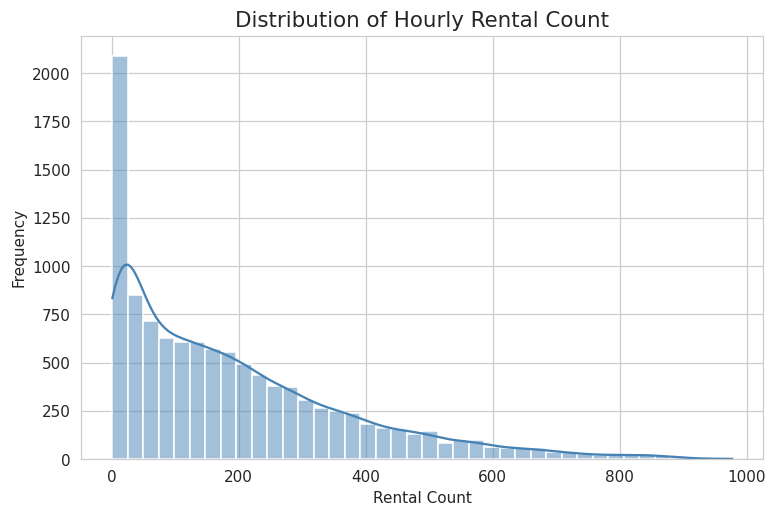

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['count'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Hourly Rental Count', fontsize=14)
plt.xlabel('Rental Count')
plt.ylabel('Frequency')
plt.show()

**What I see here:** confirms what I guessed earlier — it's skewed right. Most hours have under ~300 rentals, but there's a long tail stretching out toward ~1000 rentals, probably the busy/peak hours.

### Graph 2 — Relationship plot (Temperature vs Rental Count)

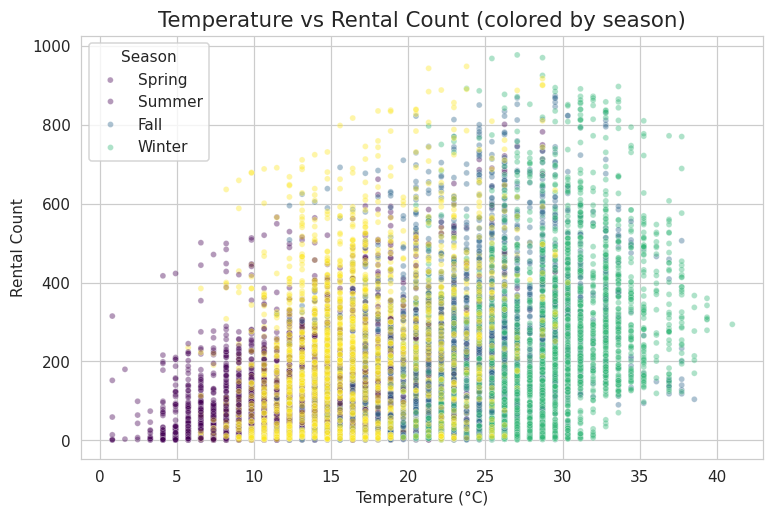

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='temp', y='count', hue='season', palette='viridis', alpha=0.4, s=15)
plt.title('Temperature vs Rental Count (colored by season)', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Rental Count')
plt.legend(title='Season', labels=['Spring','Summer','Fall','Winter'])
plt.show()

**What I see here:** rentals go up as temperature rises (people like biking when it's warm out), but at the really high end it seems to flatten out or even dip a bit. So the relationship isn't perfectly a straight line — a plain Linear Regression probably won't capture this curve fully.

### Graph 3 — Target variable plot (Average rentals by hour of day)

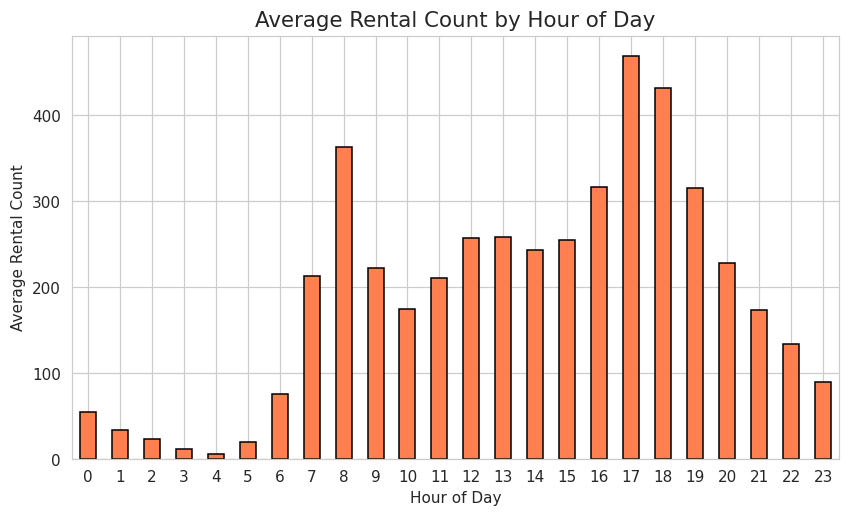

In [ ]:
# pulling out just the hour so I can group by it
df['hour'] = df['datetime'].dt.hour
hourly_avg = df.groupby('hour')['count'].mean()

plt.figure(figsize=(9, 5))
hourly_avg.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Rental Count by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Average Rental Count')
plt.xticks(rotation=0)
plt.show()

**What I see here:** two clear spikes — one around 8 AM and another around 5–6 PM, which lines up with commute times (people going to work/school, then coming back). The single highest average is at 5 PM (~469 rentals). Late at night (like 4 AM) it's almost dead. This makes me think `hour` is going to be a really important feature for the models.

### Bonus graph — Correlation heatmap

(this one wasn't explicitly required, but I added it to understand the numeric columns a bit better)

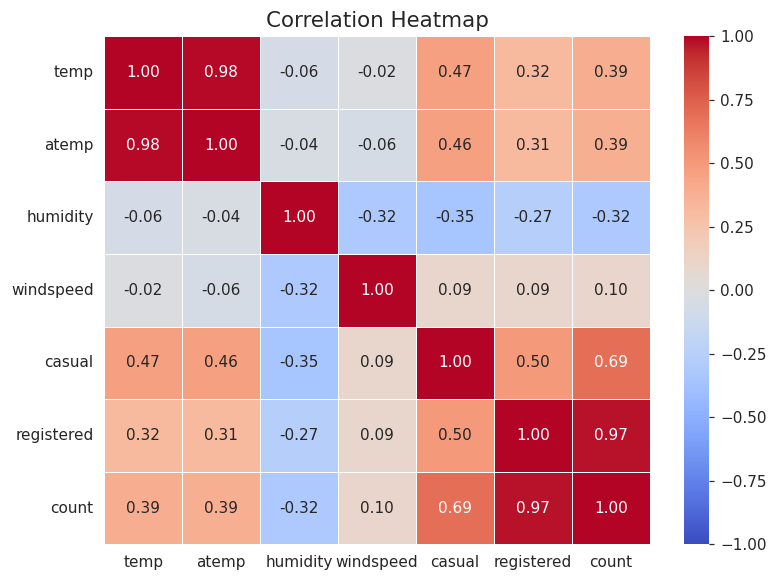

In [ ]:
corr_matrix = df[['temp','atemp','humidity','windspeed','casual','registered','count']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

**What I see here:** `temp` and `atemp` are almost perfectly correlated with each other (makes sense, `atemp` is basically the 'feels like' temperature, so it moves with `temp`). `humidity` has a mild negative correlation with `count`. `windspeed` doesn't seem to correlate much with `count` on its own.

## Step 4: Data Preprocessing

Before training anything, here's my plan for prepping the data:

- Pull `hour`, `month`, `dayofweek`, `year` out of `datetime` (the hour graph above showed it matters a lot), then drop the raw `datetime` column since models can't use it directly.
- Drop `casual` and `registered` — like I mentioned earlier, keeping them would basically let the model cheat since `count = casual + registered`.
- One-hot encode `season` and `weather` since they're categories, not real numbers — I don't want the model thinking "season 4" is somehow bigger/more than "season 1". `holiday`/`workingday` are already 0/1 so I'm leaving those as-is.
- Use the same train/test split for every model, so the comparison at the end is fair.
- Only scale the features for the models that actually need it (Logistic Regression and KNN) — tree-based models (Decision Tree, Random Forest) don't need scaling.

In [ ]:
df_model = df.copy()

# breaking datetime into separate, more useful columns
df_model['hour'] = df_model['datetime'].dt.hour
df_model['month'] = df_model['datetime'].dt.month
df_model['dayofweek'] = df_model['datetime'].dt.dayofweek
df_model['year'] = df_model['datetime'].dt.year

# one-hot encoding the category columns (season, weather) since they're not real numbers
df_model = pd.get_dummies(df_model, columns=['season', 'weather'], prefix=['season', 'weather'], drop_first=True)

# dropping the columns I don't need anymore
df_model = df_model.drop(columns=['datetime', 'casual', 'registered'])

print("Final feature set:")
print(list(df_model.columns))

Final feature set:
['holiday', 'workingday', 'temp', 'atemp', 'humidity', 'windspeed', 'count', 'hour', 'month', 'dayofweek', 'year', 'season_2', 'season_3', 'season_4', 'weather_2', 'weather_3', 'weather_4']


### Splitting into Features (X) and Target (y)

In [ ]:
X = df_model.drop(columns=['count'])   # everything except count = my features
y = df_model['count']                  # count = what I'm trying to predict

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10886, 16)
y shape: (10886,)


### Train-Test Split

In [ ]:
# 80% for training, 20% for testing
# random_state=42 just so the split is the same every time I re-run this
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows: ", X_test.shape[0])

Training rows: 8708
Testing rows:  2178


### Feature Scaling

In [ ]:
# StandardScaler makes all features have a similar scale (mean 0, std 1)
# read that this matters a lot for KNN especially, and helps Logistic Regression too
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on the training data
X_test_scaled = scaler.transform(X_test)         # only transform on test data — don't fit again, or it's data leakage

print("Scaler fit on training data only (to avoid leakage). Will be used for Logistic Regression and KNN.")

Scaler fit on training data only (to avoid leakage). Will be used for Logistic Regression and KNN.


## Step 5: Training the 5 Required Models

### Model A — Linear Regression

`count` is a number, so Linear Regression can be used in its normal, natural form here — no need to reframe it as classification.

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)
print("Linear Regression trained.")

Linear Regression trained.


In [ ]:
# checking how good the predictions are with 3 common regression metrics
mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f"MAE: {mae_lin:.2f}")
print(f"MSE: {mse_lin:.2f}")
print(f"R²:  {r2_lin:.4f}")

MAE: 105.09
MSE: 19785.56
R²:  0.4006


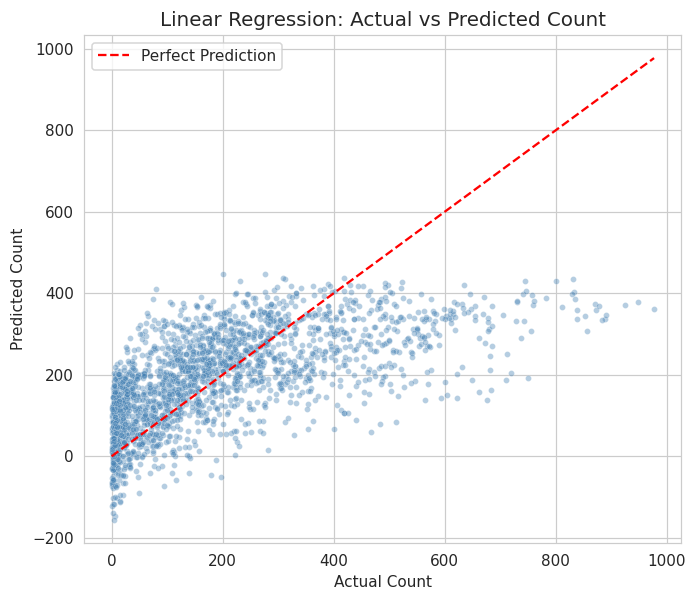

In [ ]:
# actual vs predicted — if the model was perfect, every dot would land right on the red dashed line
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred_lin, alpha=0.4, s=15, color='steelblue')
lims = [0, max(y_test.max(), y_pred_lin.max())]
plt.plot(lims, lims, color='red', linestyle='--', label='Perfect Prediction')
plt.title('Linear Regression: Actual vs Predicted Count', fontsize=13)
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.legend()
plt.show()

**My conclusion:** the model gets the overall trend, but it struggles on the high-demand hours (you can see points falling well below the red line — meaning it's under-predicting those busy hours). Probably because the real relationship isn't perfectly a straight line, similar to what I noticed with the temperature graph earlier.

### Model B — Logistic Regression

Logistic Regression needs a classification target (0/1 style), but `count` is a plain number, not a category. So I created a new target called `high_demand`:

- `high_demand = 1` if `count` is above the **median count of the training set**
- `high_demand = 0` otherwise

This basically turns "how many bikes will be rented" into a simpler yes/no question: "will this be a busier-than-usual hour or not". I calculated the median using only the training set (not the test set), so I don't accidentally leak information from the test set into the model.

In [ ]:
median_count = y_train.median()
y_train_clf = (y_train > median_count).astype(int)
y_test_clf = (y_test > median_count).astype(int)

print(f"Median rental count (train set): {median_count}")
print("\nClass balance in training set (0 = low demand, 1 = high demand):")
print(y_train_clf.value_counts())

Median rental count (train set): 145.0

Class balance in training set (0 = low demand, 1 = high demand):
count
0    4359
1    4349
Name: count, dtype: int64


In [ ]:
log_reg = LogisticRegression(max_iter=1000)   # bumped up max_iter since it gave a "didn't converge" warning with the default
log_reg.fit(X_train_scaled, y_train_clf)
y_pred_log = log_reg.predict(X_test_scaled)

acc_log = accuracy_score(y_test_clf, y_pred_log)
print(f"Accuracy: {acc_log:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test_clf, y_pred_log, target_names=['Low demand','High demand']))

Accuracy: 0.7957

Classification Report:

              precision    recall  f1-score   support

  Low demand       0.79      0.81      0.80      1093
 High demand       0.80      0.78      0.79      1085

    accuracy                           0.80      2178
   macro avg       0.80      0.80      0.80      2178
weighted avg       0.80      0.80      0.80      2178



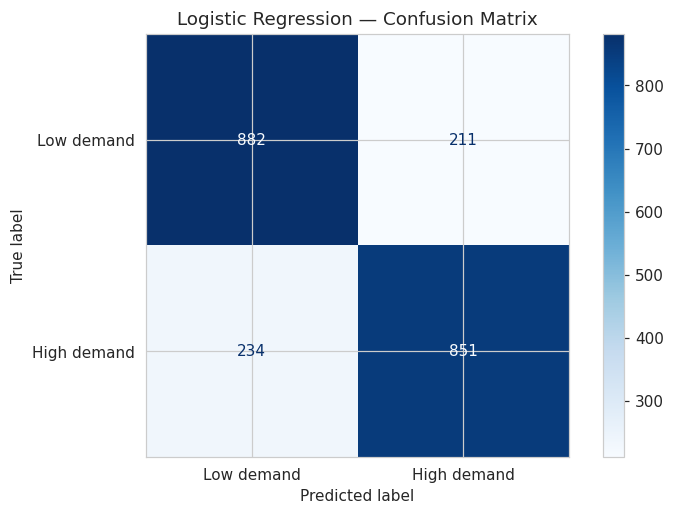

In [ ]:
cm = confusion_matrix(y_test_clf, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low demand', 'High demand'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

**What this means:** the diagonal boxes (top-left and bottom-right) are the hours the model got right, and the other two boxes are where it mixed up low/high demand. Around 80% accuracy overall, which is decent for a fairly simple model. This being higher than the R² from the regression task makes sense too — guessing 'high or low' is a much easier problem than guessing the exact count.

### Model C — Decision Tree

`count` is a number, so I used **`DecisionTreeRegressor`** here (the Classifier version is only for category targets, like the `high_demand` one I made for Logistic Regression).

In [ ]:
# max_depth=8 so the tree doesn't get insanely deep and just memorize the training data
dt_reg = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_reg.fit(X_train, y_train)
y_pred_dt = dt_reg.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print(f"MAE: {mae_dt:.2f}")
print(f"R²:  {r2_dt:.4f}")

MAE: 45.48
R²:  0.8484


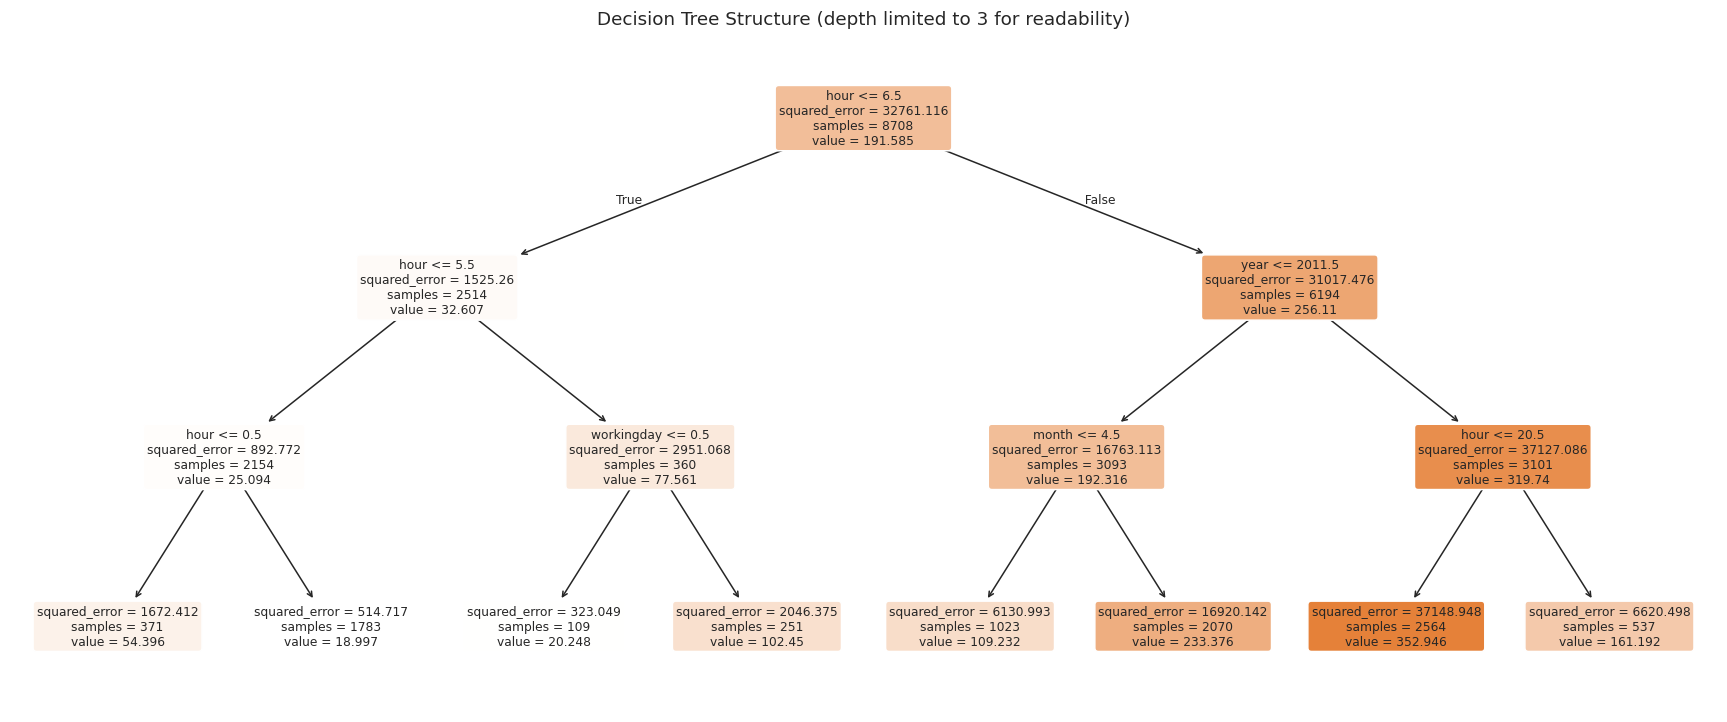

In [ ]:
# training a separate, smaller tree just so I can actually see/visualize it (depth 8 would be way too messy)
dt_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_viz.fit(X_train, y_train)

plt.figure(figsize=(20, 8))
plot_tree(dt_viz, feature_names=list(X.columns), filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree Structure (depth limited to 3 for readability)')
plt.show()

**What I notice:** the very first split the tree makes is on `hour`, which matches what I saw in the hour-of-day graph earlier — it's clearly the most useful feature. Further down it splits on things like temperature and workingday too.

### Model D — Random Forest

Same reasoning as the Decision Tree — `count` is a number, so I used **`RandomForestRegressor`**.

In [ ]:
# n_estimators=200 means it builds 200 trees and averages their predictions
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"MAE: {mae_rf:.2f}")
print(f"R²:  {r2_rf:.4f}")

MAE: 24.53
R²:  0.9534


Top 3 most important features:
hour    0.598345
year    0.085982
temp    0.058004
dtype: float64


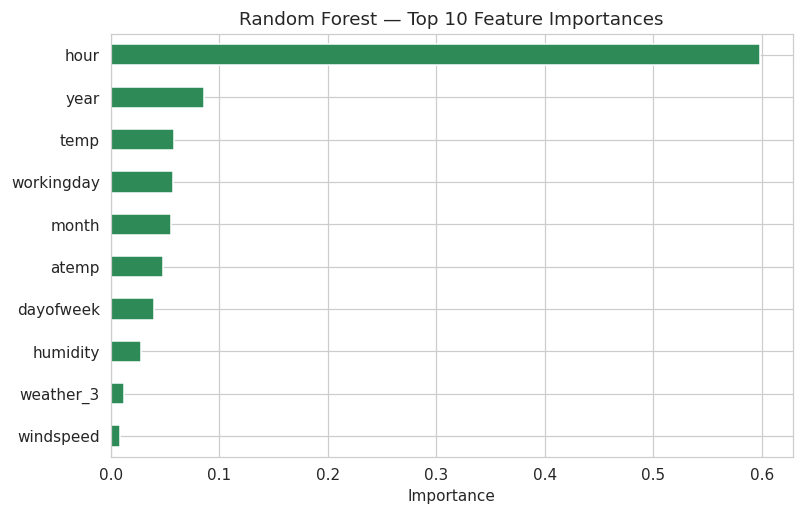

In [ ]:
# checking which features the model actually relied on the most
importances = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 3 most important features:")
print(importances.head(3))

plt.figure(figsize=(8, 5))
importances.head(10).plot(kind='barh', color='seagreen')
plt.gca().invert_yaxis()
plt.title('Random Forest — Top 10 Feature Importances')
plt.xlabel('Importance')
plt.show()

**My conclusion:** Random Forest did a lot better than both the single Decision Tree and Linear Regression. I think that's because it's basically averaging a bunch of trees together instead of relying on just one, so it doesn't overfit as much. And just like the Decision Tree, `hour` is by far the most important feature here too.

### Model E — K-Nearest Neighbors (KNN)

KNN works by measuring distance between points, so scaling really matters here — without it, a feature like `windspeed` (which goes up to ~57) would completely overpower a 0/1 dummy column in the distance calculation. I used the already-scaled features from Step 4.

In [ ]:
# starting off with K=5 as an initial guess
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)
print(f"K=5 -> MAE: {mae_knn:.2f}, R²: {r2_knn:.4f}")

K=5 -> MAE: 74.63, R²: 0.6178


In [ ]:
# trying a few different K values to see which one actually works best
k_values = [3, 5, 7, 9, 15, 25]
k_results = []

for k in k_values:
    m = KNeighborsRegressor(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    pred = m.predict(X_test_scaled)
    k_results.append({'K': k, 'MAE': round(mean_absolute_error(y_test, pred), 2), 'R2': round(r2_score(y_test, pred), 4)})

k_results_df = pd.DataFrame(k_results)
k_results_df

,K,MAE,R2
0,3,71.19,0.6323
1,5,74.63,0.6178
2,7,76.75,0.6140
3,9,78.96,0.6002
4,15,84.01,0.5744
5,25,89.49,0.5388


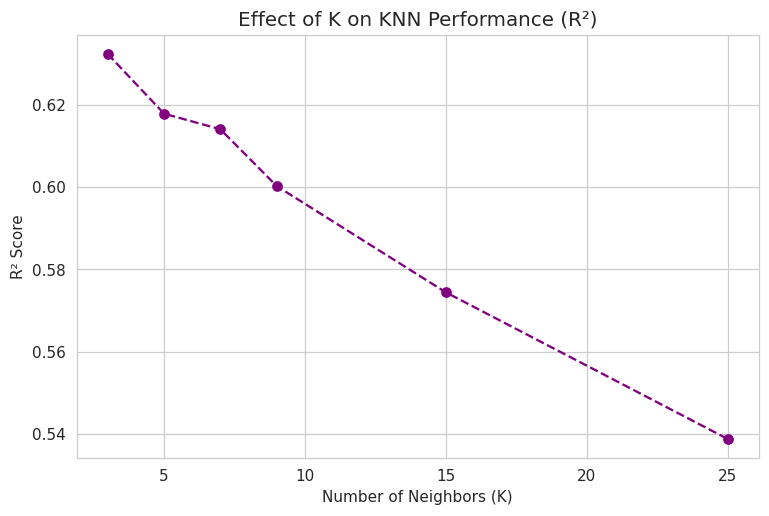

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_results_df['K'], k_results_df['R2'], marker='o', linestyle='--', color='purple')
plt.title('Effect of K on KNN Performance (R²)', fontsize=13)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('R² Score')
plt.grid(True)
plt.show()

**My conclusion:** smaller K values actually performed better here, R² kept dropping as K got bigger. I think this happens because a bigger K means the prediction gets averaged over more and more neighbors, which smooths out the sharp hour-to-hour changes that matter a lot for this data. So for this dataset, sticking to a smaller K works better (though not *too* small, or it'd start overfitting to noise instead).

## Step 6: Comparing All 5 Models

In [ ]:
# picking whichever K value gave the best R² from the table above
best_k_row = k_results_df.loc[k_results_df['R2'].idxmax()]
best_k = int(best_k_row['K'])

knn_best = KNeighborsRegressor(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn_best = knn_best.predict(X_test_scaled)
mae_knn_best = mean_absolute_error(y_test, y_pred_knn_best)
r2_knn_best = r2_score(y_test, y_pred_knn_best)

print(f"Best K for KNN: {best_k}")

Best K for KNN: 3


In [ ]:
# putting everything into one table so I can compare all 5 models side by side
comparison_df = pd.DataFrame([
    {'Model': 'Linear Regression',       'Task Type': 'Regression (count)',                 'Metric': 'R²',       'Score': round(r2_lin, 4),      'MAE': round(mae_lin, 2)},
    {'Model': 'Decision Tree',           'Task Type': 'Regression (count)',                 'Metric': 'R²',       'Score': round(r2_dt, 4),       'MAE': round(mae_dt, 2)},
    {'Model': 'Random Forest',           'Task Type': 'Regression (count)',                 'Metric': 'R²',       'Score': round(r2_rf, 4),       'MAE': round(mae_rf, 2)},
    {'Model': f'KNN (best K={best_k})',  'Task Type': 'Regression (count)',                 'Metric': 'R²',       'Score': round(r2_knn_best, 4), 'MAE': round(mae_knn_best, 2)},
    {'Model': 'Logistic Regression',     'Task Type': 'Classification (high/low demand)',   'Metric': 'Accuracy', 'Score': round(acc_log, 4),     'MAE': '—'},
]).sort_values(by='Score', ascending=False).reset_index(drop=True)

comparison_df

,Model,Task Type,Metric,Score,MAE
0,Random Forest,Regression (count),R²,0.9534,24.53
1,Decision Tree,Regression (count),R²,0.8484,45.48
2,Logistic Regression,Classification (high/low demand),Accuracy,0.7957,—
3,KNN (best K=3),Regression (count),R²,0.6323,71.19
4,Linear Regression,Regression (count),R²,0.4006,105.09


### Best vs worst model, and my final pick

Looking at the 4 models predicting the actual `count` number, **Random Forest** clearly wins (highest R², lowest MAE), and **Linear Regression** comes out worst — probably because it assumes a straight-line relationship, but the real data has curves and interactions (like hour of day) that a straight line can't really capture. Logistic Regression isn't directly comparable to the others since it's solving a different, easier problem — I'm just including it since the task asked for all 5 models.

**My final pick: Random Forest.** It gave the best accuracy, handled the skewed/messy parts of the data well, didn't need any feature scaling, and its feature-importance output also told me *why* it predicts what it predicts (`hour` being the big one) — not just a number, which feels more useful in general.

## Summary

That's the full pipeline! Quick recap of what I did:

1. Loaded the Bike Sharing Demand dataset and looked at its shape, columns, and basic stats
2. Checked for missing values and duplicates (found none of either)
3. Made 3+ graphs to understand the data better — distribution, temperature vs count, and hour vs count — plus a bonus correlation heatmap
4. Cleaned the data, engineered a few new features out of the datetime column, one-hot encoded the category columns, split into train/test, and scaled the features where it mattered
5. Trained all 5 required models — Linear Regression, Logistic Regression, Decision Tree, Random Forest, and KNN (tested with different K values)
6. Compared all 5 in one final table, and Random Forest came out on top

This was genuinely a good project to learn from — I had to go back and read the sklearn docs (linked in the task PDF) a bunch of times while doing this, especially for the scaling and encoding parts, since I'm still fairly new to this stuff. Thanks for reading through it!